In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import csv

In [2]:
import json
import os


image_path = Path('.').parent / '../maps/cdc_2024/cdc_2024_edited_with_line.pgm'
output_path = Path('.').parent / '../output'  
output_path.mkdir(exist_ok=True)

track_scale = json.load(open(os.path.join('../maps/cdc_2024', "track.json")))["scale"]

print(f"Processing {image_path}...")


Processing ../maps/cdc_2024/cdc_2024_edited_with_line.pgm...


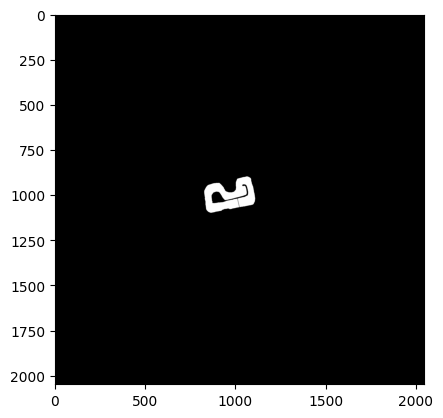

In [3]:
# Load the image
bitmap = cv2.imread(str(image_path))
if bitmap is None:
    raise ValueError(f"Could not load image from {image_path}")


plt.imshow(bitmap, cmap='gray')

In [7]:
import logging


logging.info(f"Start conversion of bitmap {image_path}.")
contours = []

# gray = cv2.cvtColor(bitmap, cv2.COLOR_BGR2GRAY)
gray = cv2.cvtColor(bitmap, cv2.COLOR_BGR2GRAY)
line_thickness=4
scale=0.2
dist_to_border=0.5


In [8]:
def export(contour: np.array, folder: str, track_name: str):
    logging.info(f"Exporting polygons of track {track_name} into folder {folder}.")
    files = [f"{track_name}_outline.csv",
                f"{track_name}_inline.csv",
                f"{track_name}_centerline.csv",
                f"{track_name}_boundingbox.csv",
                f"{track_name}_raceline.csv"]
    for file, contour in zip(files, contours):
        try:
            np.savetxt(os.path.join(folder, file), contour, delimiter=";")
            logging.info(f"Successfully wrote into {file} ({contour.shape[0]} points).")
        except Exception as e:
            logging.error(f"Exception while writing {file}: {e}")

In [9]:
import cv2
import numpy as np
import shapely
from raceline_optimization import RacelineOptimization

thresh = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY)[1]
contours1 = cv2.findContours(thresh.copy(), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
output = bitmap.copy()
for c in contours1[0]:
    c = np.squeeze(c,axis=(1,))
    if c.shape[0] < 100:
        continue
    approx = np.squeeze(cv2.approxPolyDP(c, 2, closed=True), axis=(1,))
    contours.append(approx)

skel_img = cv2.ximgproc.thinning(thresh)
skel_contour = cv2.findContours(skel_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
c = np.squeeze(skel_contour[0][0], axis=(1,))
skel_contour_approx = np.squeeze(cv2.approxPolyDP(c, 1, closed=True), axis=(1,))
contours.append(skel_contour_approx)
(x, y, w, h) = cv2.boundingRect(contours[0])
contours.append(np.asarray([(x-10, y-10), (x+w+10, y-10), (x+w+10, y+h+10), (x-10, y+h+10)]))
contours2 = [c * scale for c in contours]
contours = []
for c in contours2:
    polygon = shapely.geometry.Polygon(c)
    if not shapely.geometry.polygon.orient(polygon):
        contours.append(np.flip(c, axis=0))
    else:
        contours.append(c)

inline = shapely.Polygon(contours[1]).buffer(dist_to_border/track_scale)
outline = shapely.Polygon(contours[0]).buffer(-dist_to_border/track_scale)
raceline_optimizer = RacelineOptimization(contours[2],
                                            inline,
                                            outline)
racing_lines = raceline_optimizer.get_optimized_race_line(iterations=500)
contours.append(racing_lines)
colors = [
    (255, 255, 0),
    (0, 255, 255),
    (255, 0, 255),
    (0, 0, 255),
    (255, 0, 0)
]
for contour, color in zip(contours, colors):
    try:
        scaled_contour = np.int32((contour / scale).reshape((-1, 1, 2)))
        cv2.polylines(output, [scaled_contour], -1, color=color, thickness=line_thickness)
    except Exception as e:
        print(e)

cv2.imshow("Calculated polygons", output)
cv2.imwrite("cdc_2024-ralf.png".replace(".png", "_lines.png"), output)
export("Output", "cdc_2024")



AssertionError: inline must be a 2D array with shape (n, 2), got ()